# Неделя 2 - ETL-конвейер и очистка данных

**Проект практики:** Анализ данных государственных закупок Республики Казахстан

## Цель Недели 2

На основе находок профилирования из Недели 1 строится **ETL-конвейер** (Extract - Transform - Load),
который превращает два сырых датасета в чистые, согласованные таблицы, готовые к анализу и
моделированию.

Конвейер реализует конкретные задачи очистки, выявленные на прошлой неделе:

1. **Extract** - загрузка сырых данных.
2. **Transform** - приведение денежных столбцов из текста в числа, парсинг дат, удаление дубликатов,
   обработка пропусков по явной политике, фильтрация выбросов.
3. **Load** - сохранение очищенных датасетов в отдельные файлы (чистый слой данных).

Каждый шаг логируется, чтобы можно было проследить, сколько строк затронуто на каждом этапе.


In [1]:
# Основные импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Простой журнал ETL: накапливает шаги и число строк для прослеживаемости
etl_log = []

def log_step(stage, dataset, rows, note=""):
    etl_log.append({"этап": stage, "датасет": dataset, "строк": rows, "примечание": note})
    print(f"[ETL] {stage:<22} | {dataset:<10} | строк: {rows:>7,} | {note}")

print("Среда готова.")

Среда готова.


## 1. Extract - извлечение сырых данных

Загружаем оба датасета и фиксируем исходное число строк как отправную точку конвейера.


In [3]:
suppliers_raw = pd.read_csv("suppliers.txt")
kraska_raw    = pd.read_csv("kraska.txt")

log_step("Extract (сырые)", "suppliers", len(suppliers_raw))
log_step("Extract (сырые)", "kraska", len(kraska_raw))

# Работаем с копиями, чтобы сырые данные оставались нетронутыми
suppliers = suppliers_raw.copy()
kraska    = kraska_raw.copy()

[ETL] Extract (сырые)        | suppliers  | строк: 107,518 | 
[ETL] Extract (сырые)        | kraska     | строк:  49,123 | 


## 2. Transform - приведение денежных столбцов к числовому типу

**Находка из Недели 1:** в `suppliers` столбцы `Сумма заявки` и `Сумма лота` хранятся как текст с
запятой в качестве десятичного разделителя (например, `76339446,9`). Без приведения к числу
невозможны ни статистика, ни моделирование.

Функция `to_numeric_kz` обрабатывает десятичные запятые и неразрывные пробелы, после чего приводит
значение к `float`. Некорректные значения превращаются в `NaN` (через `errors="coerce"`), чтобы их
можно было контролируемо обработать дальше.


In [6]:
def to_numeric_kz(series):
#Преобразовать денежный текстовый столбец в формате КЗ в float.
    return pd.to_numeric(
        series.astype(str)
              .str.replace("\u00a0", "", regex=False)  # неразрывные пробелы
              .str.replace(" ", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )

# Приведение денежных столбцов в suppliers
for col in ["Сумма заявки", "Сумма лота"]:
    before_type = suppliers[col].dtype
    suppliers[col] = to_numeric_kz(suppliers[col])
    nan_after = suppliers[col].isna().sum()
    print(f"{col:<14}: {before_type} -> {suppliers[col].dtype} | NaN после: {nan_after}")

print()
print("Статистика 'Сумма заявки' (тенге) после приведения:")
print(suppliers["Сумма заявки"].describe().apply(lambda x: f"{x:,.0f}"))

Сумма заявки  : float64 -> float64 | NaN после: 64
Сумма лота    : float64 -> float64 | NaN после: 0

Статистика 'Сумма заявки' (тенге) после приведения:
count        107,454
mean       1,048,168
std       10,001,065
min                0
25%            7,750
50%           33,300
75%          182,872
max      556,827,629
Name: Сумма заявки, dtype: object


## 3. Transform - парсинг дат

Поля с датами хранятся как текст. Приводим их к типу `datetime`, чтобы можно было извлекать
компоненты (год, месяц) и корректно сортировать по времени.


In [9]:
date_cols_suppliers = ["Дата заявки", "Дата окончания лота"]
for col in date_cols_suppliers:
    suppliers[col] = pd.to_datetime(suppliers[col], errors="coerce")
    print(f"suppliers.{col:<22}: тип - {suppliers[col].dtype}, NaT: {suppliers[col].isna().sum()}")

kraska["Дата публикации"] = pd.to_datetime(kraska["Дата публикации"], errors="coerce")
print(f"kraska.Дата публикации       : тип - {kraska['Дата публикации'].dtype}, "
      f"NaT: {kraska['Дата публикации'].isna().sum()}")

suppliers.Дата заявки           : тип - datetime64[ns], NaT: 0
suppliers.Дата окончания лота   : тип - datetime64[ns], NaT: 636
kraska.Дата публикации       : тип - datetime64[ns], NaT: 0


## 4. Transform - удаление дубликатов

**Находка из Недели 1:** в обоих датасетах присутствуют полностью повторяющиеся строки
(`suppliers` - около 23.6 тыс., `kraska` - около 4.8 тыс.). Полные дубликаты не несут новой
информации и могут исказить статистику и обучение модели, поэтому удаляем их.


In [10]:
# suppliers
before = len(suppliers)
suppliers = suppliers.drop_duplicates().reset_index(drop=True)
removed = before - len(suppliers)
log_step("Удаление дубликатов", "suppliers", len(suppliers), f"удалено {removed:,}")

# kraska
before = len(kraska)
kraska = kraska.drop_duplicates().reset_index(drop=True)
removed = before - len(kraska)
log_step("Удаление дубликатов", "kraska", len(kraska), f"удалено {removed:,}")

[ETL] Удаление дубликатов    | suppliers  | строк:  83,875 | удалено 23,643
[ETL] Удаление дубликатов    | kraska     | строк:  44,305 | удалено 4,818


## 5. Transform - политика обработки пропусков

Пропуски обрабатываются не одинаково, а по явной политике, зависящей от смысла столбца:

| Столбец | Доля пропусков | Решение | Обоснование |
|---------|----------------|---------|-------------|
| `suppliers.Результат` | ~85% | Оставить как есть, добавить флаг `Есть_результат` | Пропуск структурный: результат есть только у завершённых тендеров. Удалять или заполнять нельзя - это потеря смысла. |
| `suppliers.Сумма заявки` | <0.1% | Удалить строки | Сумма - ключевое поле; без неё строка бесполезна, потеря незначительна. |
| `suppliers.КТРУ (код/имя/описание)` | ~2-3% | Заполнить меткой "Не указано" | Категориальные поля; метка сохраняет строку и явно отмечает отсутствие. |
| `kraska.Цена/Сумма заявки` | 2 строки | Удалить строки | Незначительное число, цена критична. |

Такой подход показывает осознанную работу с данными, а не слепое `dropna()`.


In [11]:
# 5.1 suppliers.Результат - структурный пропуск: создаём явный флаг, столбец не трогаем
suppliers["Есть_результат"] = suppliers["Результат"].notna()
print("Флаг 'Есть_результат' создан. Распределение:")
print(suppliers["Есть_результат"].value_counts())
print()

# 5.2 suppliers.Сумма заявки - удаляем строки без ключевой суммы
before = len(suppliers)
suppliers = suppliers.dropna(subset=["Сумма заявки"]).reset_index(drop=True)
log_step("Удаление пустой суммы", "suppliers", len(suppliers), f"удалено {before-len(suppliers):,}")

# 5.3 КТРУ-поля - заполняем явной меткой
ktru_cols = ["Код КТРУ", "Наименование КТРУ", "Описание КТРУ"]
for col in ktru_cols:
    n = suppliers[col].isna().sum()
    suppliers[col] = suppliers[col].fillna("Не указано")
    print(f"{col:<20}: заполнено {n:,} пропусков меткой 'Не указано'")

Флаг 'Есть_результат' создан. Распределение:
Есть_результат
False    69678
True     14197
Name: count, dtype: int64

[ETL] Удаление пустой суммы  | suppliers  | строк:  83,813 | удалено 62
Код КТРУ            : заполнено 1,879 пропусков меткой 'Не указано'
Наименование КТРУ   : заполнено 3,352 пропусков меткой 'Не указано'
Описание КТРУ       : заполнено 3,352 пропусков меткой 'Не указано'


In [12]:
# 5.4 kraska - удаляем 2 строки без цены/суммы заявки
before = len(kraska)
kraska = kraska.dropna(subset=["Цена заявки", "Сумма заявки"]).reset_index(drop=True)
log_step("Удаление пустой цены", "kraska", len(kraska), f"удалено {before-len(kraska):,}")

# Проверка: пропусков в ключевых столбцах больше нет
print()
print("Пропуски в ключевых числовых столбцах после очистки:")
print("suppliers.Сумма заявки:", suppliers["Сумма заявки"].isna().sum())
print("kraska.Цена заявки    :", kraska["Цена заявки"].isna().sum())

[ETL] Удаление пустой цены   | kraska     | строк:  44,303 | удалено 2

Пропуски в ключевых числовых столбцах после очистки:
suppliers.Сумма заявки: 0
kraska.Цена заявки    : 0


## 6. Transform - анализ выбросов (цена в `kraska`)

**Находка из Недели 1:** цена заявки сильно скошена вправо. Для будущей модели важно понять масштаб
выбросов. Используем метод межквартильного размаха (IQR): значения выше `Q3 + 1.5*IQR` считаются
выбросами.

Здесь выбросы **не удаляются**, а только помечаются и визуализируются - решение об их обработке
принимается на этапе моделирования (Неделя 3), где будет применено лог-преобразование.


In [13]:
price = kraska["Цена заявки"]
q1, q3 = price.quantile(0.25), price.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = max(q1 - 1.5 * iqr, 0)

kraska["Выброс_цены"] = (price > upper) | (price < lower)

n_out = kraska["Выброс_цены"].sum()
print(f"Q1 = {q1:,.0f} тг | Q3 = {q3:,.0f} тг | IQR = {iqr:,.0f} тг")
print(f"Верхняя граница выбросов: {upper:,.0f} тг")
print(f"Помечено выбросов: {n_out:,} ({n_out/len(kraska)*100:.1f}%)")

Q1 = 889 тг | Q3 = 5,788 тг | IQR = 4,899 тг
Верхняя граница выбросов: 13,136 тг
Помечено выбросов: 3,373 (7.6%)


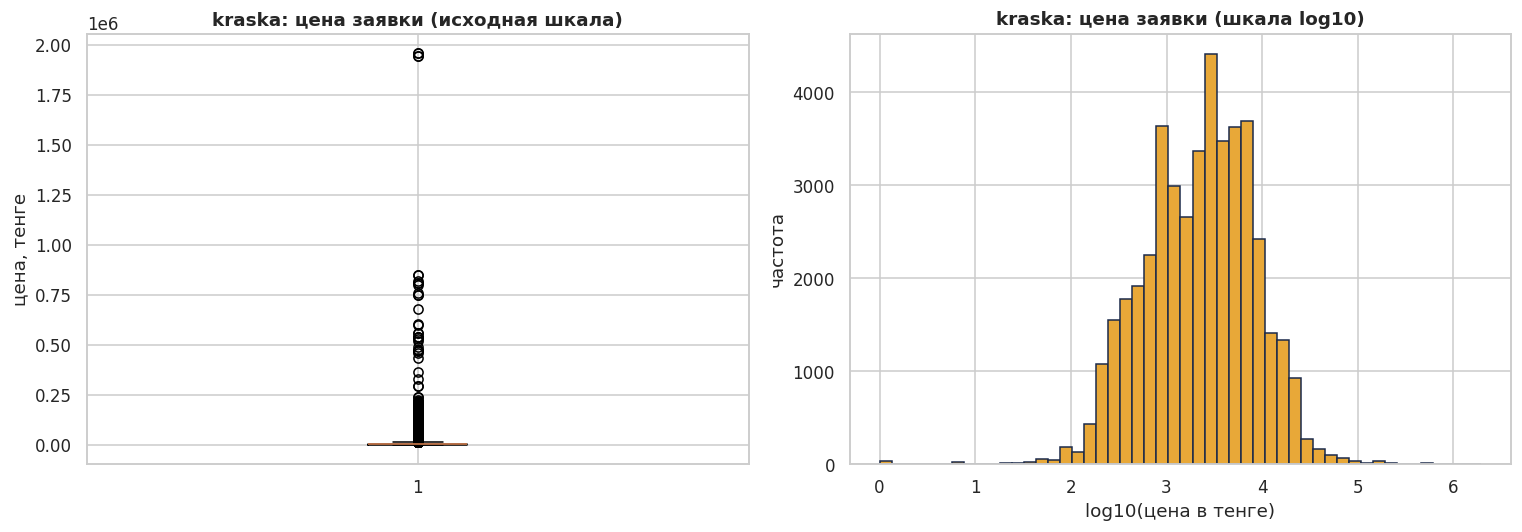

In [15]:
# Визуализация: цена до и после лог-преобразования
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(price, vert=True)
axes[0].set_title("kraska: цена заявки (исходная шкала)", fontweight="bold")
axes[0].set_ylabel("цена, тенге")

log_price = np.log10(price[price > 0])
axes[1].hist(log_price, bins=50, color="#E8A838", edgecolor="#1B2A4A")
axes[1].set_title("kraska: цена заявки (шкала log10)", fontweight="bold")
axes[1].set_xlabel("log10(цена в тенге)")
axes[1].set_ylabel("частота")

plt.tight_layout()
plt.savefig("неделя2_отклонения.png", dpi=130)
plt.show()

## 7. Transform - производные признаки

Создаём несколько полезных признаков, которые пригодятся в анализе и модели Недели 3. Это тоже часть
преобразования данных в ETL.


In [16]:
# suppliers: год и месяц из даты заявки
suppliers["Месяц_заявки"] = suppliers["Дата заявки"].dt.month

# suppliers: отношение суммы заявки к сумме лота (насколько заявка ниже/выше бюджета лота)
suppliers["Доля_от_лота"] = (
    suppliers["Сумма заявки"] / suppliers["Сумма лота"].replace(0, np.nan)
)

# kraska: бинарная целевая переменная победы (для будущей модели классификации)
kraska["Победа"] = (kraska["Результат"] == "Победитель").astype(int)

print("Созданы признаки:")
print("  suppliers.Месяц_заявки  - месяц подачи заявки")
print("  suppliers.Доля_от_лота  - сумма заявки / сумма лота")
print("  kraska.Победа           - 1 = победитель, 0 = иначе")
print()
print("Распределение целевой переменной 'Победа' в kraska:")
print(kraska["Победа"].value_counts())
print(f"Доля побед: {kraska['Победа'].mean()*100:.1f}%")

Созданы признаки:
  suppliers.Месяц_заявки  - месяц подачи заявки
  suppliers.Доля_от_лота  - сумма заявки / сумма лота
  kraska.Победа           - 1 = победитель, 0 = иначе

Распределение целевой переменной 'Победа' в kraska:
Победа
0    34676
1     9627
Name: count, dtype: int64
Доля побед: 21.7%


## 8. Load - сохранение чистого слоя данных

Очищенные датасеты сохраняются в отдельные файлы. Это формирует **чистый слой данных**: исходные
файлы остаются нетронутыми, а вся последующая работа ведётся с этими очищенными версиями.


In [18]:
suppliers.to_csv("suppliers_clean.csv", index=False)
kraska.to_csv("kraska_clean.csv", index=False)

log_step("Load (чистые)", "suppliers", len(suppliers), "- suppliers_clean.csv")
log_step("Load (чистые)", "kraska", len(kraska), "- kraska_clean.csv")

print()
print("Итоговые размеры очищенных датасетов:")
print(f"  suppliers_clean: {suppliers.shape[0]:,} строк x {suppliers.shape[1]} столбцов")
print(f"  kraska_clean   : {kraska.shape[0]:,} строк x {kraska.shape[1]} столбцов")

[ETL] Load (чистые)          | suppliers  | строк:  83,813 | - suppliers_clean.csv
[ETL] Load (чистые)          | kraska     | строк:  44,303 | - kraska_clean.csv

Итоговые размеры очищенных датасетов:
  suppliers_clean: 83,813 строк x 15 столбцов
  kraska_clean   : 44,303 строк x 18 столбцов


## 9. Сводка ETL-конвейера

Журнал шагов конвейера, собранный во время выполнения. Показывает, как менялось число строк на
каждом этапе - это прослеживаемость (data lineage) пайплайна.


In [19]:
etl_summary = pd.DataFrame(etl_log)
etl_summary

,этап,датасет,строк,примечание
0,Extract (сырые),suppliers,107518,
1,Extract (сырые),kraska,49123,
2,Extract (сырые),suppliers,107518,
3,Extract (сырые),kraska,49123,
4,Удаление дубликатов,suppliers,83875,"удалено 23,643"
5,Удаление дубликатов,kraska,44305,"удалено 4,818"
6,Удаление пустой суммы,suppliers,83813,удалено 62
7,Удаление пустой цены,kraska,44303,удалено 2
8,Load (чистые),suppliers,83813,-> suppliers_clean.csv
9,Load (чистые),kraska,44303,-> kraska_clean.csv


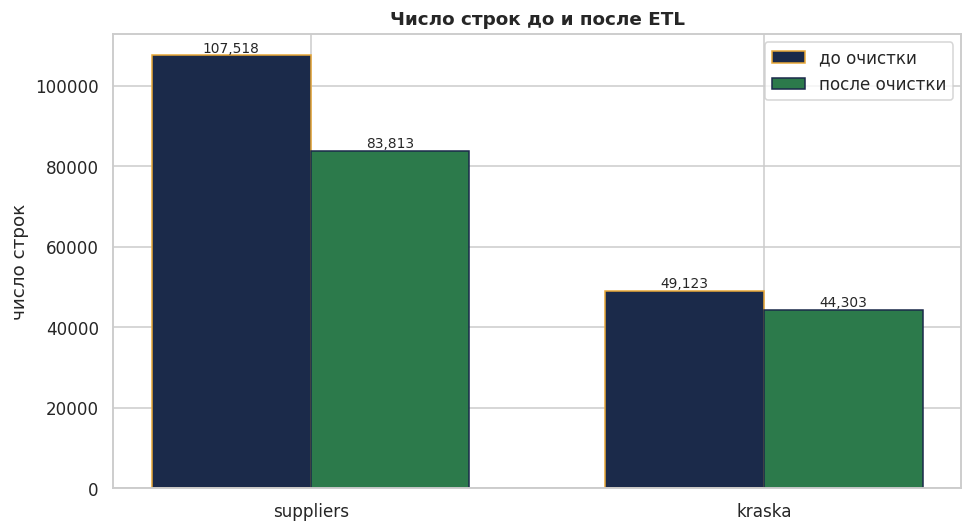

In [20]:
# Визуализация: число строк до и после очистки
fig, ax = plt.subplots(figsize=(9, 5))

datasets = ["suppliers", "kraska"]
before_vals = [len(suppliers_raw), len(kraska_raw)]
after_vals  = [len(suppliers), len(kraska)]

x = np.arange(len(datasets))
w = 0.35
ax.bar(x - w/2, before_vals, w, label="до очистки", color="#1B2A4A", edgecolor="#E8A838")
ax.bar(x + w/2, after_vals, w, label="после очистки", color="#2C7A4B", edgecolor="#1B2A4A")

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("число строк")
ax.set_title("Число строк до и после ETL", fontweight="bold")
ax.legend()

for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    ax.text(i - w/2, b, f"{b:,}", ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, a, f"{a:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("неделя2_строки_до_после.png", dpi=130)
plt.show()

## 10. Итоги Недели 2

**Что выполнено**

1. Построен ETL-конвейер по схеме Extract - Transform - Load с журналированием каждого шага.
2. Денежные столбцы приведены из текста (запятая-разделитель) к числовому типу.
3. Поля дат приведены к типу `datetime`.
4. Удалены полные дубликаты в обоих датасетах.
5. Реализована явная политика обработки пропусков (флаг для структурных, удаление для критичных,
   метка для категориальных).
6. Проанализированы и помечены выбросы цены (метод IQR), без удаления - для обработки в модели.
7. Созданы производные признаки (месяц, доля от лота, бинарная цель `Победа`).
8. Очищенные датасеты сохранены в чистый слой (`suppliers_clean.csv`, `kraska_clean.csv`).


**Готово для Недели 3:** очищенные данные с целевой переменной готовы для разведочного анализа (EDA),
статистических тестов и построения прогностической модели.
